# Visualization Quality Metrics: *Synthetic Data*

This notebook computes Trustworthiness, Continuity, Spearman Correlation, and DEMaP for each dimensionality reduction method (PCA, UMAP, PHATE, PaCMAP) on LLM-generated synthetic hierarchical datasets.

Embeddings and reduced embeddings are loaded from precomputed `.npy` files generated by `eval_script.py`.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import phate
import pacmap
import umap as umap_pkg
from sklearn.decomposition import PCA as skPCA
from sklearn.manifold import trustworthiness
from sklearn.metrics import pairwise_distances
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import shortest_path
from scipy.stats import spearmanr

# navigate to src/ from wherever the notebook is run
current = os.path.abspath('.')
while os.path.basename(current) != 'src' and current != os.path.dirname(current):
    current = os.path.dirname(current)
src_dir = current
os.chdir(src_dir)
sys.path.insert(0, src_dir)

/Applications/anaconda3/envs/phate-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Setup

Change the parameters here to select which synthetic dataset to evaluate. The `stem` variable is automatically built from the config. Available themes: `Energy_Ecosystems_and_Humans`, `Offshore_energy_impacts_on_fisheries`.

In [2]:
# config: change these parameters to match the synthetic dataset you want to evaluate
embedding_model  = "sentence-transformers/all-MiniLM-L6-v2"
theme            = "Energy_Ecosystems_and_Humans"  # options: Energy_Ecosystems_and_Humans, Offshore_energy_impacts_on_fisheries
t                = 1.0
max_sub          = 3 #  options: 3, 5
depth            = 5 #  options: 3, 5
synonyms         = 0
branching        = "random"
add_noise        = 0.25

# build filename stem from config
if add_noise > 0:
    stem = f"{theme}_hierarchy_t{t}_maxsub{max_sub}_depth{depth}_synonyms{synonyms}_noise{add_noise}_{branching}"
else:
    stem = f"{theme}_hierarchy_t{t}_maxsub{max_sub}_depth{depth}_synonyms{synonyms}_{branching}"

embedding_dir = f"intermediate_data/{embedding_model}_embeddings"
reduction_dir = f"intermediate_data/{embedding_model}_reduced_embeddings"
results_dir   = f"intermediate_data/{embedding_model}_results"
os.makedirs(results_dir, exist_ok=True)

print(f"Stem: {stem}")
print(f"Embedding dir: {embedding_dir}")
print(f"Reduction dir: {reduction_dir}")
print(f"Results dir:   {results_dir}")

Stem: Energy_Ecosystems_and_Humans_hierarchy_t1.0_maxsub3_depth5_synonyms0_noise0.25_random
Embedding dir: intermediate_data/sentence-transformers/all-MiniLM-L6-v2_embeddings
Reduction dir: intermediate_data/sentence-transformers/all-MiniLM-L6-v2_reduced_embeddings
Results dir:   intermediate_data/sentence-transformers/all-MiniLM-L6-v2_results


## 2. Load Embeddings

Load precomputed embeddings from `eval_script.py` output. To generate these, run:

```bash
python src/run_models/synthetic_data/eval_script.py --theme Energy_Ecosystems_and_Humans --t 1.0 --max_sub 3 --depth 5 --synonyms 0 --branching random
```

In [3]:
# load precomputed high-dimensional embeddings
embed_path = f"{embedding_dir}/{stem}_embed.npy"
x_high = np.load(embed_path)
print(f"Embeddings shape: {x_high.shape}")

Embeddings shape: (2000, 384)


## 3. Compute 2D Reductions

All four methods are run natively at 2D directly from the high-dimensional embeddings. PCA uses SVD (components ordered by variance). PHATE uses classic MDS (components ordered by eigenvalue). UMAP and PaCMAP are run at `n_components=2` — slicing the first 2 columns of a higher-dimensional embedding is not valid for these methods since they are optimization-based with no component ordering. Results are cached in `intermediate_data/{embedding_model}_reduced_2d/` for fast re-runs.

In [4]:
reduction_2d_dir = f"intermediate_data/{embedding_model}_reduced_2d"
os.makedirs(reduction_2d_dir, exist_ok=True)

# subsample for large datasets before running 2D reductions (pairwise distances scale as n^2)
# synthetic datasets in this project are all under 3500 points so subsampling will not occur
max_samples = 5000
if x_high.shape[0] > max_samples:
    np.random.seed(42)
    sub_idx = np.random.choice(x_high.shape[0], max_samples, replace=False)
    x_high_sub = x_high[sub_idx]
    print(f"Subsampled to {max_samples} points for 2D reduction and metrics")
else:
    x_high_sub = x_high
    print(f"No subsampling needed ({x_high.shape[0]} points)")

def load_or_compute_2d(name, path, compute_fn):
    if os.path.exists(path):
        print(f"Loading cached 2D {name} from {path}...")
        return np.load(path)
    print(f"Computing 2D {name}...")
    result = compute_fn()
    np.save(path, result)
    print(f"Saved to {path}")
    return result

reductions = {}

reductions["PCA"] = load_or_compute_2d(
    "PCA", f"{reduction_2d_dir}/PCA_2d_{stem}.npy",
    lambda: skPCA(n_components=2, random_state=67).fit_transform(x_high_sub)
)
reductions["UMAP"] = load_or_compute_2d(
    "UMAP", f"{reduction_2d_dir}/UMAP_2d_{stem}.npy",
    lambda: umap_pkg.UMAP(n_components=2, min_dist=0.05, n_neighbors=10, random_state=67).fit_transform(x_high_sub)
)
reductions["PHATE"] = load_or_compute_2d(
    "PHATE", f"{reduction_2d_dir}/PHATE_2d_{stem}.npy",
    lambda: phate.PHATE(n_jobs=-2, random_state=67, n_components=2, mds="classic").fit_transform(x_high_sub)
)
reductions["PaCMAP"] = load_or_compute_2d(
    "PaCMAP", f"{reduction_2d_dir}/PaCMAP_2d_{stem}.npy",
    lambda: pacmap.PaCMAP(n_components=2, random_state=67).fit_transform(x_high_sub)
)

for name, arr in reductions.items():
    print(f"{name}: {arr.shape}")

No subsampling needed (2000 points)
Loading cached 2D PCA from intermediate_data/sentence-transformers/all-MiniLM-L6-v2_reduced_2d/PCA_2d_Energy_Ecosystems_and_Humans_hierarchy_t1.0_maxsub3_depth5_synonyms0_noise0.25_random.npy...
Loading cached 2D UMAP from intermediate_data/sentence-transformers/all-MiniLM-L6-v2_reduced_2d/UMAP_2d_Energy_Ecosystems_and_Humans_hierarchy_t1.0_maxsub3_depth5_synonyms0_noise0.25_random.npy...
Loading cached 2D PHATE from intermediate_data/sentence-transformers/all-MiniLM-L6-v2_reduced_2d/PHATE_2d_Energy_Ecosystems_and_Humans_hierarchy_t1.0_maxsub3_depth5_synonyms0_noise0.25_random.npy...
Loading cached 2D PaCMAP from intermediate_data/sentence-transformers/all-MiniLM-L6-v2_reduced_2d/PaCMAP_2d_Energy_Ecosystems_and_Humans_hierarchy_t1.0_maxsub3_depth5_synonyms0_noise0.25_random.npy...
PCA: (2000, 2)
UMAP: (2000, 2)
PHATE: (2000, 2)
PaCMAP: (2000, 2)


## 4. Metrics

- **Trustworthiness**: measures whether neighbors in low-dim space were also neighbors in high-dim space (local structure preservation)
- **Continuity**: measures whether neighbors in high-dim space are preserved in low-dim space (reverse of trustworthiness)
- **Spearman Correlation**: rank correlation of raw pairwise Euclidean distances high-dim vs 2D
- **DEMaP** (Moon et al. 2019): Spearman correlation of geodesic distances (k-NN shortest paths) in high-dim vs Euclidean distances in 2D; better captures true manifold structure than raw Euclidean

Trustworthiness and Continuity range from 0 to 1, higher is better. Spearman and DEMaP range from -1 to 1, where 1 is perfect preservation and 0 means no relationship. The synthetic datasets have explicit hierarchical structure, so higher DEMaP scores are expected on shallow hierarchies (depth3). Deeper hierarchies (depth5) create finer distinctions that may not survive compression to 2D, so scores there may be closer to 0.

In [5]:
def compute_continuity(x_high, x_low, n_neighbors=15):
    n = x_high.shape[0]

    d_high = pairwise_distances(x_high)
    d_low  = pairwise_distances(x_low)
    rank_low = np.argsort(np.argsort(d_low, axis=1), axis=1)

    continuity = 0.0
    for i in range(n):
        neighbors_high = set(np.argsort(d_high[i])[1:n_neighbors+1])
        neighbors_low  = set(np.argsort(d_low[i])[1:n_neighbors+1])
        missing = neighbors_high - neighbors_low
        for j in missing:
            continuity += rank_low[i, j] - n_neighbors

    norm = 2.0 / (n * n_neighbors * (2 * n - 3 * n_neighbors - 1))
    return 1 - norm * continuity

In [6]:
def compute_demap(x_high, x_low_2d, n_neighbors=5):
    # DEMaP: geodesic distances (k-NN shortest path) in high-dim vs Euclidean in 2D
    # Moon et al. 2019 (PHATE paper), k=5 to emphasize local structure
    knn = kneighbors_graph(x_high, n_neighbors=n_neighbors, mode='distance', include_self=False)
    geo = shortest_path(knn, directed=False)

    # replace inf (disconnected pairs) with 1 + max finite distance
    # treats disconnected pairs as maximally far rather than dropping them
    max_finite = np.nanmax(geo[np.isfinite(geo)])
    geo[np.isinf(geo)] = 1 + max_finite

    idx = np.triu_indices(x_high.shape[0], k=1)
    geo_flat = geo[idx]
    euc_flat = pairwise_distances(x_low_2d)[idx]

    return spearmanr(geo_flat, euc_flat)[0]

In [7]:
stats = []

# x_high_sub and reductions are already subsampled and computed natively at 2D in the loading cell above
for name, x_low_2d in reductions.items():
    t_score = trustworthiness(x_high_sub, x_low_2d, n_neighbors=15)
    c_score = compute_continuity(x_high_sub, x_low_2d, n_neighbors=15)

    # spearman correlation of raw pairwise Euclidean distances
    d_high = pairwise_distances(x_high_sub).flatten()
    d_low  = pairwise_distances(x_low_2d).flatten()
    spearman_corr, _ = spearmanr(d_high, d_low)

    # DEMaP: geodesic distances in high-dim vs Euclidean in 2D (Moon et al. 2019)
    # k=5 keeps the graph sparse to preserve manifold structure; disconnected pairs
    # are handled by replacing inf with 1+max finite distance (not dropped)
    print(f"  Computing DEMaP for {name}...")
    demap_score = compute_demap(x_high_sub, x_low_2d, n_neighbors=5)

    stats.append({
        "Method": name,
        "Trustworthiness": round(t_score, 4),
        "Continuity": round(c_score, 4),
        "Spearman Correlation": round(spearman_corr, 4),
        "DEMaP": round(demap_score, 4)
    })
    print(f"{name}: Trustworthiness={t_score:.4f}, Continuity={c_score:.4f}, Spearman={spearman_corr:.4f}, DEMaP={demap_score:.4f}")

pd.DataFrame(stats)

  Computing DEMaP for PCA...
PCA: Trustworthiness=0.7816, Continuity=0.8972, Spearman=0.3488, DEMaP=0.2448
  Computing DEMaP for UMAP...
UMAP: Trustworthiness=0.9632, Continuity=0.9571, Spearman=0.3038, DEMaP=0.4220
  Computing DEMaP for PHATE...
PHATE: Trustworthiness=0.8007, Continuity=0.9367, Spearman=0.3984, DEMaP=0.4862
  Computing DEMaP for PaCMAP...
PaCMAP: Trustworthiness=0.9531, Continuity=0.9535, Spearman=0.3828, DEMaP=0.4334


,Method,Trustworthiness,Continuity,Spearman Correlation,DEMaP
0,PCA,0.7816,0.8972,0.3488,0.2448
1,UMAP,0.9632,0.9571,0.3038,0.4220
2,PHATE,0.8007,0.9367,0.3984,0.4862
3,PaCMAP,0.9531,0.9535,0.3828,0.4334


In [8]:
output_path = os.path.join(results_dir, f"viz_metrics_{stem}.csv")
pd.DataFrame(stats).to_csv(output_path, index=False)
print(f"Saved to {output_path}")

Saved to intermediate_data/sentence-transformers/all-MiniLM-L6-v2_results/viz_metrics_Energy_Ecosystems_and_Humans_hierarchy_t1.0_maxsub3_depth5_synonyms0_noise0.25_random.csv


## 5. Shepard Diagrams

Compares pairwise distances in the original high-dimensional space against the reduced space. Points close to the red diagonal indicate better global distance preservation.

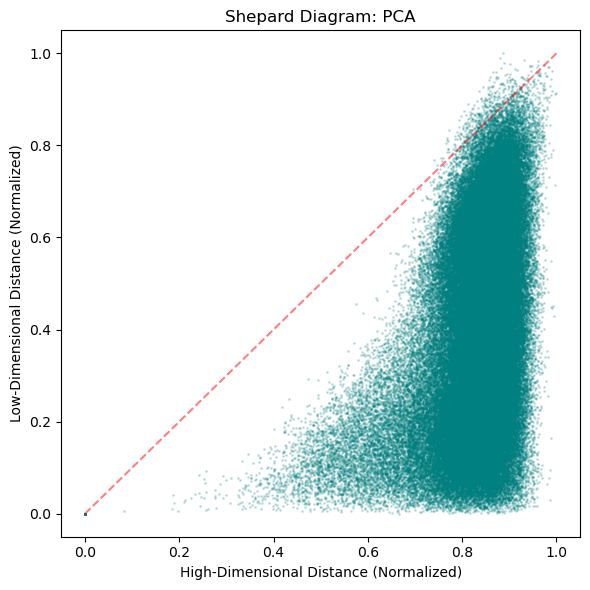

Saved: intermediate_data/sentence-transformers/all-MiniLM-L6-v2_results/shepard_Energy_Ecosystems_and_Humans_hierarchy_t1.0_maxsub3_depth5_synonyms0_noise0.25_random_pca.png


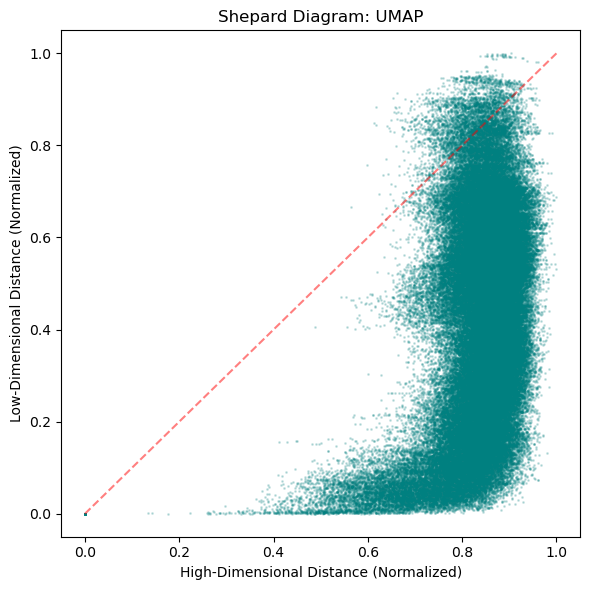

Saved: intermediate_data/sentence-transformers/all-MiniLM-L6-v2_results/shepard_Energy_Ecosystems_and_Humans_hierarchy_t1.0_maxsub3_depth5_synonyms0_noise0.25_random_umap.png


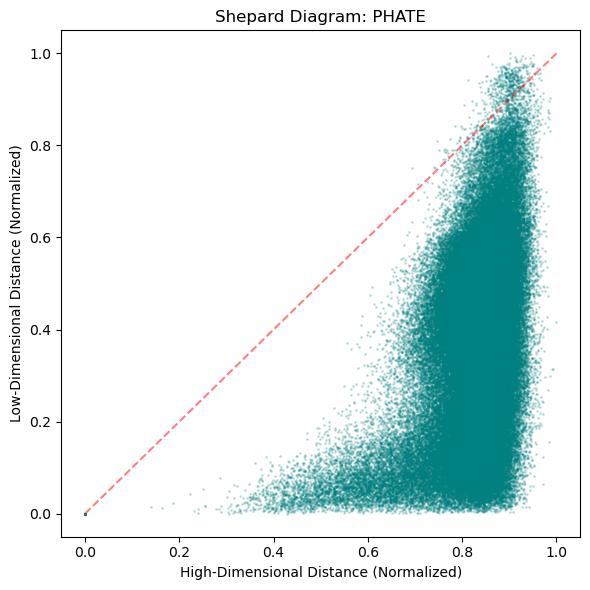

Saved: intermediate_data/sentence-transformers/all-MiniLM-L6-v2_results/shepard_Energy_Ecosystems_and_Humans_hierarchy_t1.0_maxsub3_depth5_synonyms0_noise0.25_random_phate.png


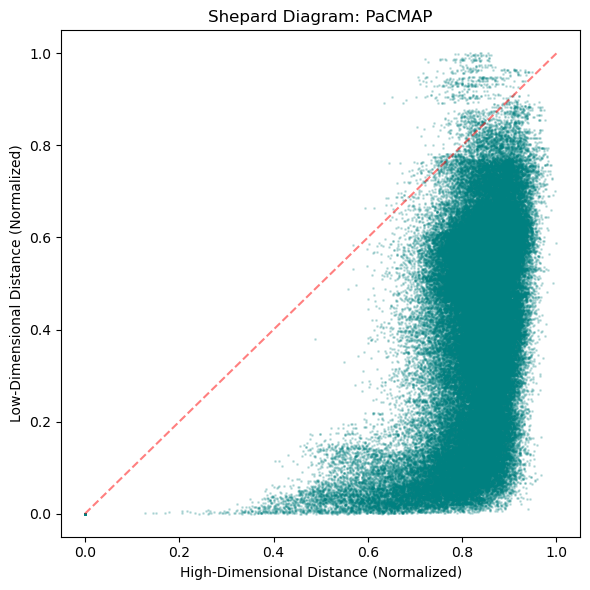

Saved: intermediate_data/sentence-transformers/all-MiniLM-L6-v2_results/shepard_Energy_Ecosystems_and_Humans_hierarchy_t1.0_maxsub3_depth5_synonyms0_noise0.25_random_pacmap.png


In [9]:
def plot_shepard(x_high, x_low, name, sample_size=500):
    indices = np.random.choice(len(x_high), min(sample_size, len(x_high)), replace=False)

    d_high = pairwise_distances(x_high[indices]).flatten()
    d_low  = pairwise_distances(x_low[indices]).flatten()

    d_high = d_high / np.max(d_high)
    d_low  = d_low  / np.max(d_low)

    plt.figure(figsize=(6, 6))
    plt.scatter(d_high, d_low, alpha=0.1, s=1, color='teal')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--', alpha=0.5)
    plt.title(f"Shepard Diagram: {name}")
    plt.xlabel("High-Dimensional Distance (Normalized)")
    plt.ylabel("Low-Dimensional Distance (Normalized)")
    plt.tight_layout()

    filename = os.path.join(results_dir, f"shepard_{stem}_{name.lower()}.png")
    plt.savefig(filename, dpi=300)
    plt.show()
    return filename

for name, x_low_2d in reductions.items():
    f = plot_shepard(x_high_sub, x_low_2d, name)
    print(f"Saved: {f}")

## 6. Results

Results using `all-MiniLM-L6-v2` embeddings projected natively to 2D. DEMaP uses k=5 neighbors; disconnected pairs set to 1+max distance.

---

### Energy Ecosystems and Humans: maxsub5, depth3

**Clean (832 documents)**

| Method | Trustworthiness | Continuity | Spearman | DEMaP |
|--------|----------------|------------|----------|-------|
| PCA | 0.7813 | 0.8738 | 0.4969 | 0.4815 |
| UMAP | 0.9490 | 0.9307 | 0.4535 | 0.6623 |
| PHATE | 0.7938 | 0.8965 | 0.4259 | 0.6205 |
| PaCMAP | 0.9376 | 0.9200 | 0.3846 | 0.6068 |

**25% noise (1040 documents)**

| Method | Trustworthiness | Continuity | Spearman | DEMaP |
|--------|----------------|------------|----------|-------|
| PCA | 0.7559 | 0.8760 | 0.3044 | 0.2899 |
| UMAP | 0.9449 | 0.9348 | 0.3935 | 0.5851 |
| PHATE | 0.7665 | 0.8953 | 0.2530 | 0.4569 |
| PaCMAP | 0.9358 | 0.9087 | 0.2163 | 0.3602 |

**50% noise (1248 documents)**

| Method | Trustworthiness | Continuity | Spearman | DEMaP |
|--------|----------------|------------|----------|-------|
| PCA | 0.7592 | 0.8879 | 0.3919 | 0.4418 |
| UMAP | 0.9425 | 0.9397 | 0.4246 | 0.6430 |
| PHATE | 0.7505 | 0.8935 | 0.2528 | 0.4546 |
| PaCMAP | 0.9364 | 0.9342 | 0.4071 | 0.6054 |

---

### Energy Ecosystems and Humans: maxsub3, depth5

**Clean (1600 documents)**

| Method | Trustworthiness | Continuity | Spearman | DEMaP |
|--------|----------------|------------|----------|-------|
| PCA | 0.7917 | 0.8953 | 0.5318 | 0.4741 |
| UMAP | 0.9678 | 0.9590 | 0.5081 | 0.6610 |
| PHATE | 0.7914 | 0.9200 | 0.4755 | 0.5854 |
| PaCMAP | 0.9567 | 0.9435 | 0.4876 | 0.5823 |

**25% noise (2000 documents)**

| Method | Trustworthiness | Continuity | Spearman | DEMaP |
|--------|----------------|------------|----------|-------|
| PCA | 0.7816 | 0.8972 | 0.3488 | 0.2448 |
| UMAP | 0.9632 | 0.9571 | 0.3038 | 0.4220 |
| PHATE | 0.8007 | 0.9367 | 0.3984 | 0.4862 |
| PaCMAP | 0.9531 | 0.9535 | 0.3828 | 0.4334 |

**50% noise (2400 documents)**

| Method | Trustworthiness | Continuity | Spearman | DEMaP |
|--------|----------------|------------|----------|-------|
| PCA | 0.7831 | 0.9039 | 0.3952 | 0.2600 |
| UMAP | 0.9568 | 0.9547 | 0.3187 | 0.4419 |
| PHATE | 0.8644 | 0.9424 | 0.2960 | 0.3722 |
| PaCMAP | 0.9428 | 0.9462 | 0.3799 | 0.3997 |

---

### Offshore Energy Impacts on Fisheries: maxsub5, depth3

**Clean (745 documents)**

| Method | Trustworthiness | Continuity | Spearman | DEMaP |
|--------|----------------|------------|----------|-------|
| PCA | 0.7611 | 0.8643 | 0.4614 | 0.3375 |
| UMAP | 0.9418 | 0.9331 | 0.4249 | 0.6085 |
| PHATE | 0.7374 | 0.8891 | 0.4051 | 0.6118 |
| PaCMAP | 0.9389 | 0.9161 | 0.3638 | 0.5334 |

**25% noise (931 documents)**

| Method | Trustworthiness | Continuity | Spearman | DEMaP |
|--------|----------------|------------|----------|-------|
| PCA | 0.7357 | 0.8712 | 0.4575 | 0.3342 |
| UMAP | 0.9371 | 0.9327 | 0.2150 | 0.4605 |
| PHATE | 0.7415 | 0.9083 | 0.1218 | 0.4423 |
| PaCMAP | 0.9284 | 0.9185 | 0.1384 | 0.3712 |

**50% noise (1117 documents)**

| Method | Trustworthiness | Continuity | Spearman | DEMaP |
|--------|----------------|------------|----------|-------|
| PCA | 0.7309 | 0.8827 | 0.4575 | 0.4458 |
| UMAP | 0.9324 | 0.9397 | 0.2152 | 0.4935 |
| PHATE | 0.7150 | 0.8951 | 0.0878 | 0.4172 |
| PaCMAP | 0.9202 | 0.9252 | 0.2597 | 0.4208 |

---

### Offshore Energy Impacts on Fisheries: maxsub3, depth5

**Clean (2293 documents)**

| Method | Trustworthiness | Continuity | Spearman | DEMaP |
|--------|----------------|------------|----------|-------|
| PCA | 0.7815 | 0.8887 | 0.5454 | 0.4640 |
| UMAP | 0.9684 | 0.9605 | 0.4714 | 0.7056 |
| PHATE | 0.8314 | 0.9382 | 0.5039 | 0.7287 |
| PaCMAP | 0.9516 | 0.9510 | 0.4320 | 0.6353 |

**25% noise (2866 documents)**

| Method | Trustworthiness | Continuity | Spearman | DEMaP |
|--------|----------------|------------|----------|-------|
| PCA | 0.7459 | 0.8920 | 0.3853 | 0.2398 |
| UMAP | 0.9632 | 0.9616 | 0.3923 | 0.5811 |
| PHATE | 0.8581 | 0.9516 | 0.4438 | 0.6609 |
| PaCMAP | 0.9460 | 0.9552 | 0.3103 | 0.4558 |

**50% noise (3439 documents)**

| Method | Trustworthiness | Continuity | Spearman | DEMaP |
|--------|----------------|------------|----------|-------|
| PCA | 0.7398 | 0.9013 | 0.4243 | 0.3129 |
| UMAP | 0.9587 | 0.9626 | 0.3743 | 0.5388 |
| PHATE | 0.8236 | 0.9459 | 0.2941 | 0.4851 |
| PaCMAP | 0.9311 | 0.9551 | 0.3592 | 0.4889 |

## 7. Discussion

**UMAP and PaCMAP consistently led on Trustworthiness across all configs and noise levels:** UMAP reaches 0.94-0.97 and PaCMAP 0.92-0.96. PHATE and PCA scored lower on Trustworthiness (0.71-0.86) but were more competitive on DEMaP, consistent with their design for manifold structure rather than local neighborhood preservation.

**Depth5 configs outperformed depth3 configs on most metrics:** Offshore depth5 clean produced the highest DEMaP of any config: PHATE 0.7287, UMAP 0.7056. Deeper hierarchies with more levels create a richer embedding geometry that 2D reductions can partially recover.

**PHATE led on DEMaP for the Offshore depth5 config:** reaching 0.7287 vs UMAP's 0.7056. This is the only config where PHATE outperforms UMAP on DEMaP, and it aligns with PHATE's design for capturing branching manifold structure.

**Noise degraded scores but did not eliminate structure:** even at 50% noise, DEMaP scores remained in the 0.3-0.6 range across most configs. The degradation was gradual rather than sharp in most cases.

**The Offshore maxsub5_depth3 config showed a divergence between Spearman and DEMaP under noise:** Spearman dropped sharply with noise (0.46 clean to 0.22 at 25% and 50%) while DEMaP stayed relatively stable (0.34 clean to 0.46 at 50%). This suggests the manifold structure is more robust to noise than the raw Euclidean distance structure.

**Trustworthiness and Continuity remained high across all noise levels:** confirming these local metrics are not sensitive to noise in the embedding space. DEMaP and Spearman are the more informative metrics for tracking structural degradation.